# 모기 비행 궤적 데이터 분포 분석

학습 데이터(8,000개) 기준으로 다음 세 가지 분포를 시각화합니다:
- **변위 크기**: 각 타임스텝에서 원점(t=0 위치)으로부터의 3D 거리
- **속도 크기**: 연속 타임스텝 간 이동 거리 / Δt (Δt = 40ms)
- **가속도 크기**: 속도 변화량 / Δt

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
import os

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
})

SEED = 42
DT = 0.040  # 40ms between timesteps (seconds)
TIMESTEPS_MS = [-400, -360, -320, -280, -240, -200, -160, -120, -80, -40, 0]

# 경로 설정 (노트북 위치에 상관없이 작동하도록 절대 경로 또는 상위 경로 탐색)
current_dir = Path(os.getcwd())
if (current_dir / 'data').exists():
    DATA_DIR = current_dir / 'data'
else:
    DATA_DIR = current_dir.parent / 'data'

CACHE_DIR = DATA_DIR / '.cache'
print(f"Data Directory: {DATA_DIR}")
print(f"Cache Directory: {CACHE_DIR}")

Data Directory: c:\Users\haiya\kimenu\DACON\Mosquito flight trajectory\data
Cache Directory: c:\Users\haiya\kimenu\DACON\Mosquito flight trajectory\data\.cache


## 1. 데이터 로드 (캐시 우선 로드)

In [17]:
# 8000개로 시작하는 학습용 캐시 파일 찾기
cache_files = list(CACHE_DIR.glob('8000_TRAIN_*.npz'))

if cache_files:
    cache_file = cache_files[0]
    print(f'캐시 발견: {cache_file}')
    data = np.load(cache_file, allow_pickle=True)
    raw = data['sequences']
    file_ids = data['file_ids']
    print(f'캐시로부터 {len(raw)}개 샘플을 로드했습니다.')
else:
    # 캐시가 없을 경우의 폴백 로직
    print('지정된 8000개 캐시 파일을 찾을 수 없습니다. 경로와 파일명을 확인해주세요.')
    # 여기서 에러를 발생시켜 이후 셀 실행 방지
    raise FileNotFoundError(f"{CACHE_DIR}에서 8000_TRAIN_*.npz 파일을 찾을 수 없습니다.")

print(f'\nLoaded shape: {raw.shape}  →  (샘플 수, 타임스텝 수, xyz)')

Data Directory: c:\Users\haiya\kimenu\DACON\Mosquito flight trajectory\data
Cache Directory: c:\Users\haiya\kimenu\DACON\Mosquito flight trajectory\data\.cache


## 2. 통계량 계산

- **원점(기준점)**: 각 궤적의 마지막 위치(t = 0ms)  
- **변위 크기** = ‖pos(t) − pos(0)‖₂  
- **속도 크기** = ‖pos(t+1) − pos(t)‖₂ / Δt  
- **가속도 크기** = ‖vel(t+1) − vel(t)‖₂ / Δt

In [18]:
# 기준점: 각 시퀀스의 마지막(t=0ms) 위치
last_pos = raw[:, -1:, :]           # (N, 1, 3)
disp = raw - last_pos               # (N, 11, 3)  상대 변위
disp_mag = np.linalg.norm(disp, axis=-1)  # (N, 11)  변위 크기

# 속도: 연속 타임스텝 차이 / dt
vel = np.diff(raw, axis=1) / DT    # (N, 10, 3)
vel_mag = np.linalg.norm(vel, axis=-1)    # (N, 10)

# 가속도: 속도의 차이 / dt
acc = np.diff(vel, axis=1) / DT    # (N, 9, 3)
acc_mag = np.linalg.norm(acc, axis=-1)    # (N, 9)

print('변위 크기 (m)   - mean: {:.3f},  std: {:.3f},  max: {:.3f}'.format(
    disp_mag.mean(), disp_mag.std(), disp_mag.max()))
print('속도 크기 (m/s) - mean: {:.3f},  std: {:.3f},  max: {:.3f}'.format(
    vel_mag.mean(), vel_mag.std(), vel_mag.max()))
print('가속도 크기 (m/s²) - mean: {:.3f},  std: {:.3f},  max: {:.3f}'.format(
    acc_mag.mean(), acc_mag.std(), acc_mag.max()))

Data Directory: c:\Users\haiya\kimenu\DACON\Mosquito flight trajectory\data
Cache Directory: c:\Users\haiya\kimenu\DACON\Mosquito flight trajectory\data\.cache


## 3. 분포 시각화

NameError: name 'disp_mag' is not defined

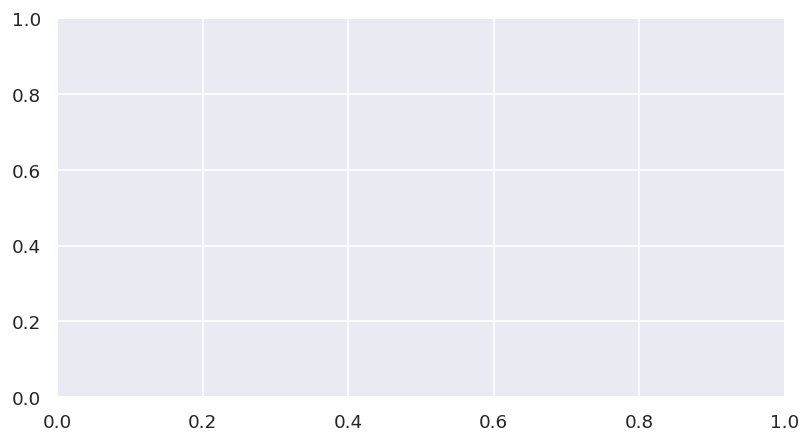

In [19]:
TIMESTEP_LABELS = [f'{t}ms' for t in TIMESTEPS_MS]  # 11 steps
VEL_LABELS = [f'{TIMESTEPS_MS[i]}→{TIMESTEPS_MS[i+1]}ms' for i in range(10)]
ACC_LABELS = [f'{TIMESTEPS_MS[i]}→{TIMESTEPS_MS[i+2]}ms' for i in range(9)]

COLORS = sns.color_palette('coolwarm', 11)

fig = plt.figure(figsize=(18, 16))
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.3)

# ── (A) 변위 크기: 전체 분포 히스토그램 ─────────────────────────────────
ax_a = fig.add_subplot(gs[0, 0])
ax_a.hist(disp_mag.ravel(), bins=120, color='steelblue', edgecolor='none', alpha=0.85)
ax_a.axvline(np.percentile(disp_mag, 95), color='tomato', lw=1.5,
             linestyle='--', label='95th pct')
ax_a.set_xlabel('변위 크기 (m)', fontsize=12)
ax_a.set_ylabel('빈도', fontsize=12)
ax_a.set_title('(A) 변위 크기 전체 분포', fontsize=13, fontweight='bold')
ax_a.legend()

# ── (B) 변위 크기: 타임스텝별 박스플롯 ──────────────────────────────────
ax_b = fig.add_subplot(gs[0, 1])
ax_b.boxplot(
    [disp_mag[:, t] for t in range(11)],
    labels=TIMESTEP_LABELS,
    patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.6),
    medianprops=dict(color='white', linewidth=2),
    flierprops=dict(marker='.', markersize=2, alpha=0.3),
    showfliers=True,
)
ax_b.set_xlabel('타임스텝', fontsize=12)
ax_b.set_ylabel('변위 크기 (m)', fontsize=12)
ax_b.set_title('(B) 타임스텝별 변위 크기 분포', fontsize=13, fontweight='bold')
ax_b.tick_params(axis='x', rotation=45)

# ── (C) 속도 크기: 전체 분포 히스토그램 ─────────────────────────────────
ax_c = fig.add_subplot(gs[1, 0])
ax_c.hist(vel_mag.ravel(), bins=120, color='mediumseagreen', edgecolor='none', alpha=0.85)
ax_c.axvline(np.percentile(vel_mag, 95), color='tomato', lw=1.5,
             linestyle='--', label='95th pct')
ax_c.set_xlabel('속도 크기 (m/s)', fontsize=12)
ax_c.set_ylabel('빈도', fontsize=12)
ax_c.set_title('(C) 속도 크기 전체 분포', fontsize=13, fontweight='bold')
ax_c.legend()

# ── (D) 속도 크기: 구간별 박스플롯 ──────────────────────────────────────
ax_d = fig.add_subplot(gs[1, 1])
ax_d.boxplot(
    [vel_mag[:, t] for t in range(10)],
    labels=[f'{TIMESTEPS_MS[i]}→\n{TIMESTEPS_MS[i+1]}' for i in range(10)],
    patch_artist=True,
    boxprops=dict(facecolor='mediumseagreen', alpha=0.6),
    medianprops=dict(color='white', linewidth=2),
    flierprops=dict(marker='.', markersize=2, alpha=0.3),
)
ax_d.set_xlabel('구간 (ms)', fontsize=12)
ax_d.set_ylabel('속도 크기 (m/s)', fontsize=12)
ax_d.set_title('(D) 구간별 속도 크기 분포', fontsize=13, fontweight='bold')
ax_d.tick_params(axis='x', rotation=0)

# ── (E) 가속도 크기: 전체 분포 히스토그램 ───────────────────────────────
ax_e = fig.add_subplot(gs[2, 0])
ax_e.hist(acc_mag.ravel(), bins=120, color='mediumpurple', edgecolor='none', alpha=0.85)
ax_e.axvline(np.percentile(acc_mag, 95), color='tomato', lw=1.5,
             linestyle='--', label='95th pct')
ax_e.set_xlabel('가속도 크기 (m/s²)', fontsize=12)
ax_e.set_ylabel('빈도', fontsize=12)
ax_e.set_title('(E) 가속도 크기 전체 분포', fontsize=13, fontweight='bold')
ax_e.legend()

# ── (F) 가속도 크기: 구간별 박스플롯 ────────────────────────────────────
ax_f = fig.add_subplot(gs[2, 1])
ax_f.boxplot(
    [acc_mag[:, t] for t in range(9)],
    labels=[f'{TIMESTEPS_MS[i]}→\n{TIMESTEPS_MS[i+2]}' for i in range(9)],
    patch_artist=True,
    boxprops=dict(facecolor='mediumpurple', alpha=0.6),
    medianprops=dict(color='white', linewidth=2),
    flierprops=dict(marker='.', markersize=2, alpha=0.3),
)
ax_f.set_xlabel('구간 (ms)', fontsize=12)
ax_f.set_ylabel('가속도 크기 (m/s²)', fontsize=12)
ax_f.set_title('(F) 구간별 가속도 크기 분포', fontsize=13, fontweight='bold')
ax_f.tick_params(axis='x', rotation=0)

fig.suptitle(f'모기 비행 궤적 물리량 분포 (Train {len(raw):,}개 샘플)',
             fontsize=16, fontweight='bold', y=1.01)
plt.savefig('eda_distributions.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: eda_distributions.png')

## 4. 타임스텝별 평균 물리량 추이

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# 변위 크기 평균/표준편차 추이
ax = axes[0]
mean_d = disp_mag.mean(axis=0)
std_d  = disp_mag.std(axis=0)
ax.plot(TIMESTEPS_MS, mean_d, 'o-', color='steelblue', lw=2, label='Mean')
ax.fill_between(TIMESTEPS_MS, mean_d - std_d, mean_d + std_d,
                color='steelblue', alpha=0.2, label='±1 Std')
ax.set_xlabel('타임스텝 (ms)', fontsize=11)
ax.set_ylabel('변위 크기 (m)', fontsize=11)
ax.set_title('변위 크기 추이', fontsize=12, fontweight='bold')
ax.legend()
ax.invert_xaxis()

# 속도 크기 평균/표준편차 추이
ax = axes[1]
vel_midpoints = [(TIMESTEPS_MS[i] + TIMESTEPS_MS[i+1]) / 2 for i in range(10)]
mean_v = vel_mag.mean(axis=0)
std_v  = vel_mag.std(axis=0)
ax.plot(vel_midpoints, mean_v, 's-', color='mediumseagreen', lw=2, label='Mean')
ax.fill_between(vel_midpoints, mean_v - std_v, mean_v + std_v,
                color='mediumseagreen', alpha=0.2, label='±1 Std')
ax.set_xlabel('구간 중점 (ms)', fontsize=11)
ax.set_ylabel('속도 크기 (m/s)', fontsize=11)
ax.set_title('속도 크기 추이', fontsize=12, fontweight='bold')
ax.legend()
ax.invert_xaxis()

# 가속도 크기 평균/표준편차 추이
ax = axes[2]
acc_midpoints = [(TIMESTEPS_MS[i] + TIMESTEPS_MS[i+2]) / 2 for i in range(9)]
mean_a = acc_mag.mean(axis=0)
std_a  = acc_mag.std(axis=0)
ax.plot(acc_midpoints, mean_a, '^-', color='mediumpurple', lw=2, label='Mean')
ax.fill_between(acc_midpoints, mean_a - std_a, mean_a + std_a,
                color='mediumpurple', alpha=0.2, label='±1 Std')
ax.set_xlabel('구간 중점 (ms)', fontsize=11)
ax.set_ylabel('가속도 크기 (m/s²)', fontsize=11)
ax.set_title('가속도 크기 추이', fontsize=12, fontweight='bold')
ax.legend()
ax.invert_xaxis()

fig.suptitle('타임스텝별 평균 물리량 추이 (shaded = ±1 std)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_timewise.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: eda_timewise.png')

## 5. 퍼센타일 요약 테이블

In [ ]:
pcts = [0, 5, 25, 50, 75, 95, 99, 100]

rows = {
    '변위 크기 (m)':    np.percentile(disp_mag.ravel(), pcts),
    '속도 크기 (m/s)':  np.percentile(vel_mag.ravel(), pcts),
    '가속도 크기 (m/s²)': np.percentile(acc_mag.ravel(), pcts),
}

summary = pd.DataFrame(rows, index=[f'P{p}' for p in pcts]).T
display(summary.round(4))